# Simulation

To complement our **exploratory data analysis**, simulation studies will be performed in this notebook, especially to visualize the differences between the two variants conversion distributions.

Let's first analyze each variant data individually and, then, visualize both at the same time!

## Importing

In [1]:
# Importing necessary functions and libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Individual analysis

In [2]:
# Generating data for variant A to visualize the distribution of conversions 
# when the number of samples (of size n) is large
generated_array_a = np.random.binomial(n=100, p=0.12, size=10000)

In [7]:
# Creating a personalized bin list so that the bars are centered on integer values
bins = np.arange(generated_array_a.min(), generated_array_a.max() + 2) - 0.5

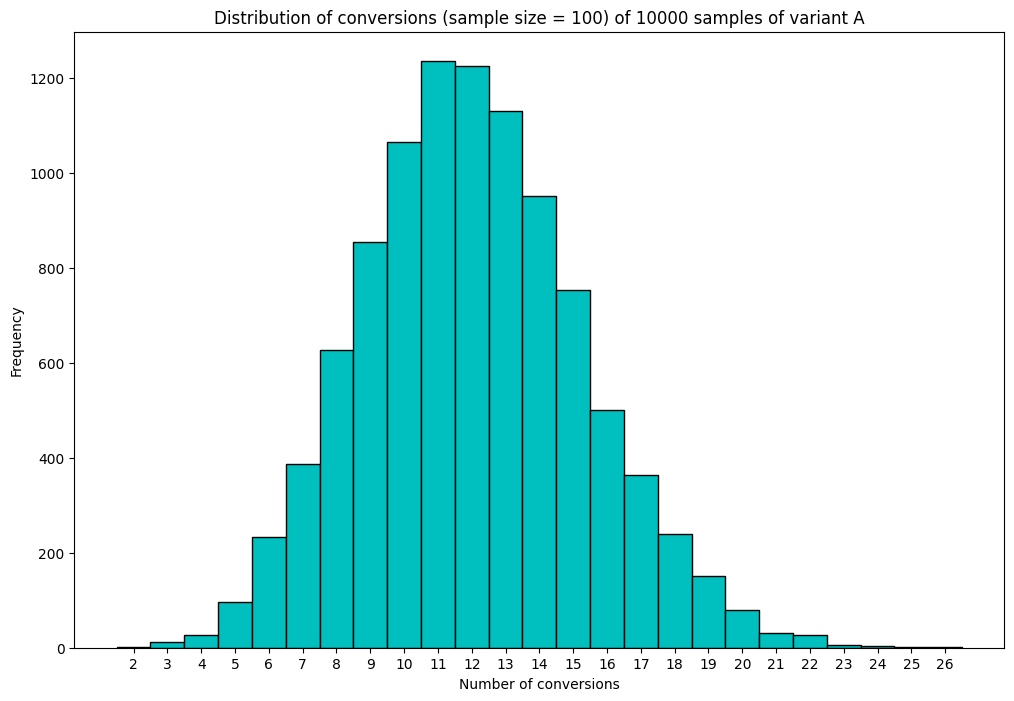

In [10]:
# Making the graph
plt.figure(figsize=(12, 8))
plt.hist(generated_array_a, color="c", bins=bins, edgecolor="black")
plt.title("Distribution of conversions (sample size = 100) of 10000 samples of variant A")
plt.xlabel("Number of conversions")
plt.xticks(np.arange(generated_array_a.min(), generated_array_a.max() + 1))
plt.ylabel("Frequency")
plt.show()

From the graph above, we see that the mode (most frequent value) is 11, which makes sense, since we generated the data for the A variant with $\theta = 0.12$. 

It is known that the expected value of a random variable $X \sim Binomial(n, \theta)$ is equal to $n \theta$

Also, from the ratio between the probability of consecutive values from the Binomial distribution, follows that the mode is given by $\lfloor n\theta + \theta \rfloor$.

Since $\theta \in (0, 1)$, the mode of X can only be, at maximum, 1 unit away from the mean. From the expression of the mode, we get that it should be 12, which makes sense and is coherent with the visual inspection of the histogram.

Another interesting thing is that **X** normally doesn't have a symetric distribution. In this case, the distribution is symetric, because the **assymptotic theorems** kick in, especially the **Law of Large Numbers** and the **Central Limit Theorem**

Let's do the same thing for variant B

In [4]:
# Generating data for variant B to visualize the distribution of conversions 
# when the number of samples (of size n) is large
generated_array_b = np.random.binomial(n=100, p=0.15, size=10000)

In [11]:
# Creating a personalized bin list so that the bars are centered on integer values
bins = np.arange(generated_array_b.min(), generated_array_b.max() + 2) - 0.5

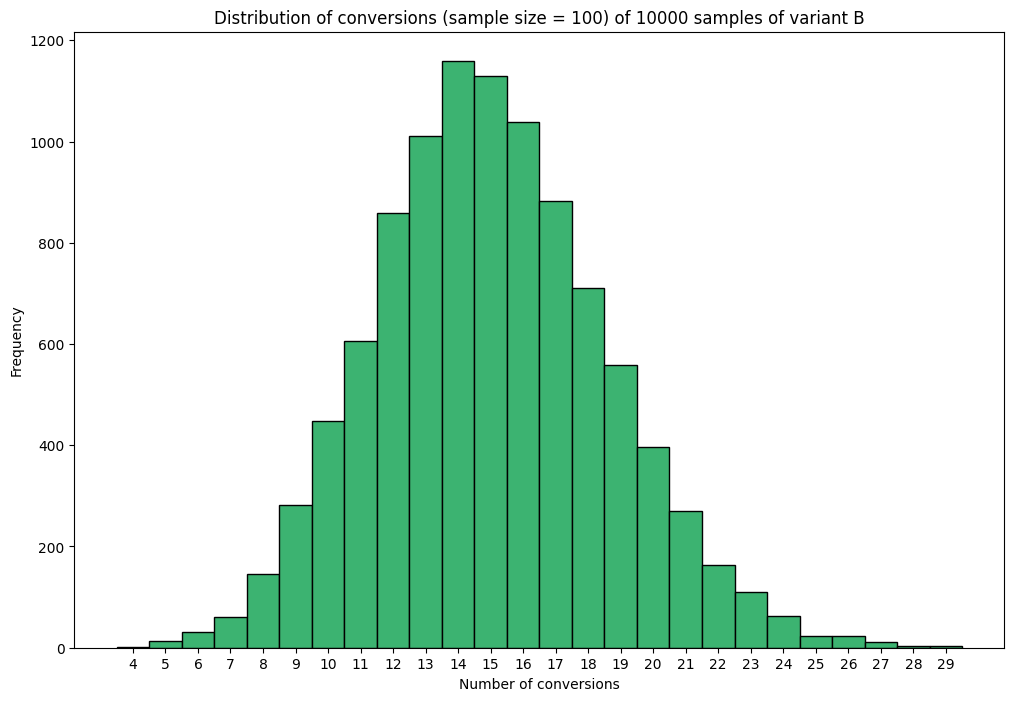

In [13]:
# Making the graph
plt.figure(figsize=(12, 8))
plt.hist(generated_array_b, color="mediumseagreen", bins=bins, edgecolor="black")
plt.title("Distribution of conversions (sample size = 100) of 10000 samples of variant B")
plt.xlabel("Number of conversions")
plt.xticks(np.arange(generated_array_b.min(), generated_array_b.max() + 1))
plt.ylabel("Frequency")
plt.show()

Similar remarks can be made to the distribution of variant B, with the difference being that the mode is 14, which makes sense knowing that we generated its data with $\theta = 0.15$

## Joint analysis

Let's know try to visualize both distributions at the same time!

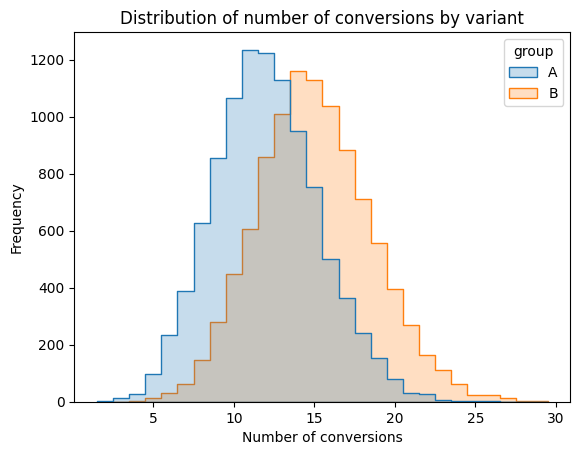

In [6]:
# Since seaborn will be used, the data will be organized in the DataFrame as follows
conversion_a_df = pd.DataFrame({"group": "A", "conversion": generated_array_a})
conversion_b_df = pd.DataFrame({"group": "B", "conversion": generated_array_b})
conversion_df = pd.concat([conversion_a_df, conversion_b_df], axis=0)
ax = sns.histplot(data=conversion_df, x="conversion", hue="group", discrete=True, legend=True, element="step")
ax.set_xlabel("Number of conversions")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of number of conversions by variant")
plt.show()

Analyzing the generated visualization, it's clear that variant B tends to have a higher number of conversions, almost as it is a positive offset of the distribution of conversions from variant A (which is caused by the higher value for the $\theta$ parameter for variant B)